# (Mixtral) AI System for Automatic Cognitive-Level Question Generation
## RAG + LLM + ModernBERT Bloom Taxonomy Classifier

This notebook implements the research pipeline described in **"Automatic Bloom's Taxonomy Question Generation Using RAG and ModernBERT Classification with Regenerative Feedback"**.

**Pipeline Architecture:**

| Phase | Component | Description |
|-------|-----------|-------------|
| **1A** | Knowledge Base | Load → preprocess → chunk → embed → store learning materials in Qdrant vector DB |
| **1B** | Classifier | Load pre-trained **ModernBERT** fine-tuned for Bloom's Taxonomy (C1–C6) |
| **2**  | RAG + LLM | Retrieve relevant context → generate questions with a local LLM via **Ollama** |
| **3**  | Evaluation + Feedback Loop | Classify generated question → compare with target → regenerate if non-ideal (max **3** attempts) |
| **4**  | Efficiency Instrumentation | Log per-call latency, throughput, GPU power draw, and energy/cost per question |

**Key updates from the original paper:**
- Classifier: SVM + TF-IDF → **pre-trained ModernBERT** (`manzarimalik/ModernBERT-Bloom-Taxonomy`)
- Language: Bahasa Indonesia → **English**
- Framework: built end-to-end with **LangChain**
- LLM runtime: local **Ollama** (`Mistral:7b`), matching the paper's local-deployment setup — *not* the Groq cloud API
- **New in this version:** wall-clock timing is recorded at every retrieval, generation, and classification call, enabling latency, throughput, and energy/cost reporting (Section 5) to support the "scalable" claim made in the paper with quantitative evidence.


---
## 1. Setup — Install Dependencies

Run this cell once per Colab session. It installs LangChain, Qdrant, Transformers, and Groq.

In [3]:
# Run this once per Colab session
%pip install -q -U \
    langchain \
    langchain-core \
    langchain-community \
    langchain-groq \
    langchain-huggingface \
    langchain-qdrant \
    langchain-text-splitters \
    qdrant-client \
    sentence-transformers \
    transformers \
    accelerate \
    datasets \
    pynvml \
    seaborn \
    langchain-ollama \

print("\n✅ Dependencies installed. Restart the runtime if Colab asks you to.")

Note: you may need to restart the kernel to use updated packages.

✅ Dependencies installed. Restart the runtime if Colab asks you to.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 2. Imports

In [34]:
import os
import re
import json
import time
from getpass import getpass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# ── Transformers (Bloom classifier) ─────────────────────────────────
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
)

# ── LangChain core ───────────────────────────────────────────────────
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_text_splitters import RecursiveCharacterTextSplitter

# ── LangChain integrations ───────────────────────────────────────────
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_ollama import ChatOllama

# ── Qdrant (vector DB) ───────────────────────────────────────────────
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams

# ── Evaluation ───────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

# ── Efficiency instrumentation (NEW) ─────────────────────────────────
# pynvml lets us read live GPU power draw (Watts) on NVIDIA cards.
# If it's not installed or no NVIDIA GPU is present, we degrade gracefully
# and energy/cost columns will simply report as unavailable (NaN).
try:
    import pynvml
    pynvml.nvmlInit()
    _NVML_HANDLE = pynvml.nvmlDeviceGetHandleByIndex(0)
    _NVML_AVAILABLE = True
except Exception:
    _NVML_AVAILABLE = False
    _NVML_HANDLE = None

print("✅ Imports OK")
print(f"   GPU available     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU device        : {torch.cuda.get_device_name(0)}")
print(f"   NVML power logging: {'available' if _NVML_AVAILABLE else 'unavailable (pip install pynvml if you want live Watt readings)'}")

✅ Imports OK
   GPU available     : True
   GPU device        : NVIDIA GeForce RTX 3060
   NVML power logging: available


In [36]:
import sys
import torch

print("Python executable:")
print(sys.executable)

print("\nTorch location:")
print(torch.__file__)

print("\nTorch version:")
print(torch.__version__)

print("\nCUDA version:")
print(torch.version.cuda)

print("\nCUDA available:")
print(torch.cuda.is_available())

Python executable:
c:\Users\s2\AppData\Local\Programs\Python\Python311\python.exe

Torch location:
c:\Users\s2\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\__init__.py

Torch version:
2.11.0+cu128

CUDA version:
12.8

CUDA available:
True


---
## 3. Configuration

Set API keys and model names. **You need a free Groq API key** — sign up at https://console.groq.com/keys.

In [37]:
# ── API KEYS ─────────────────────────────────────────────────────────
# Get a free key at: https://console.groq.com/keys
# if "GROQ_API_KEY" not in os.environ:
#     os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")


# ── MODEL CONFIGURATION ──────────────────────────────────────────────
EMBEDDING_MODEL          = "sentence-transformers/all-MiniLM-L6-v2"
CLASSIFIER_MODEL         = "manzarimalik/ModernBERT-Bloom-Taxonomy"
CLASSIFIER_BASE_TOKENIZER = "answerdotai/ModernBERT-base"

# ── VECTOR STORE ─────────────────────────────────────────────────────
COLLECTION_NAME = "learning_materials"
CHUNK_SIZE      = 500
CHUNK_OVERLAP   = 50
TOP_K           = 3   # number of retrieved chunks per query

# ── FEEDBACK LOOP ────────────────────────────────────────────────────
# NOTE: must match the paper's stated protocol ("maximum of three attempts").
# A previous version of this notebook accidentally called the resumable
# evaluation runner with max_attempts=2 — fixed below (Section 6) to use
# this constant consistently everywhere instead of a hardcoded literal.
MAX_REGENERATION_ATTEMPTS = 3

# ── RATE LIMITING ────────────────────────────────────────────────────
# LLM_CALL_DELAY_SEC = 2.0   # jeda antar LLM call (detik). Naikkan kalau masih kena limit.

# ── EFFICIENCY / COST INSTRUMENTATION (NEW) ──────────────────────────
# Electricity tariff used to convert measured GPU energy (kWh) into a
# rough monetary cost figure for the paper's efficiency table.
# Adjust ELECTRICITY_TARIFF_PER_KWH to your local currency/rate as needed.
ELECTRICITY_TARIFF_PER_KWH = 1500.0   # IDR per kWh (PLN average residential rate, indicative)
ELECTRICITY_CURRENCY        = "IDR"
# Fallback "typical load" power draw (Watts) used ONLY if pynvml is unavailable,
# so the notebook can still produce an (explicitly labeled) rough estimate
# rather than silently omitting the cost column. RTX 3060 TDP ≈ 170W.
FALLBACK_GPU_POWER_WATTS = 170.0

# ── BLOOM'S TAXONOMY MAPPING ─────────────────────────────────────────
# ModernBERT-Bloom-Taxonomy outputs label_0 … label_5 by default.
# If the model card already provides id2label, the pipeline will pick it up;
# this dict acts as a safe fallback / canonical mapping.
BLOOM_LABEL_MAP = {
    # Label format yang dipakai manzarimalik/ModernBERT-Bloom-Taxonomy
    "BT1": "Remember",
    "BT2": "Understand",
    "BT3": "Apply",
    "BT4": "Analyze",
    "BT5": "Evaluate",
    "BT6": "Create",
    # Fallback generic HuggingFace labels
    "LABEL_0": "Remember",
    "LABEL_1": "Understand",
    "LABEL_2": "Apply",
    "LABEL_3": "Analyze",
    "LABEL_4": "Evaluate",
    "LABEL_5": "Create",
}

BLOOM_TO_C = {
    "Remember":   "C1",
    "Understand": "C2",
    "Apply":      "C3",
    "Analyze":    "C4",
    "Evaluate":   "C5",
    "Create":     "C6",
}

BLOOM_ORDER = ["Remember", "Understand", "Apply", "Analyze", "Evaluate", "Create"]

print("✅ Configuration set")
print(f"   MAX_REGENERATION_ATTEMPTS = {MAX_REGENERATION_ATTEMPTS}")
print(f"   Electricity tariff        = {ELECTRICITY_TARIFF_PER_KWH} {ELECTRICITY_CURRENCY}/kWh")

✅ Configuration set
   MAX_REGENERATION_ATTEMPTS = 3
   Electricity tariff        = 1500.0 IDR/kWh


---
# 📚 PHASE 1A — Knowledge Base Construction

Steps:
1. Load learning-material documents
2. Preprocess + chunk into concept-sized units
3. Embed each chunk with a sentence-transformer
4. Store embeddings in an in-memory **Qdrant** vector database

### 3.1 Load Learning Materials

The dataset should contain at least four columns:
- `content`  — the actual paragraph / passage
- `topic`    — sub-topic name
- `subject`  — subject area (Biology, History, …)
- `keywords` — comma-separated keywords

Replace the sample data below with your own English-language CSV
(e.g. `pd.read_csv("materials.csv")`).

In [39]:
# ── Sample English learning materials (replace with your dataset) ────
# sample_materials = [
#     {
#         "content": (
#             "Photosynthesis is the biological process by which green plants, "
#             "algae, and certain bacteria convert light energy, usually from the sun, "
#             "into chemical energy stored in glucose. The process occurs primarily in "
#             "the chloroplasts of plant cells, where the green pigment chlorophyll "
#             "absorbs light. The overall chemical equation is "
#             "6CO2 + 6H2O + light → C6H12O6 + 6O2. Photosynthesis has two main stages: "
#             "the light-dependent reactions and the Calvin cycle (light-independent reactions)."
#         ),
#         "topic":    "Photosynthesis",
#         "subject":  "Biology",
#         "keywords": "photosynthesis, chlorophyll, chloroplast, glucose, Calvin cycle",
#     },
#     {
#         "content": (
#             "Newton's three laws of motion form the foundation of classical mechanics. "
#             "The first law (law of inertia) states that an object at rest stays at rest "
#             "and an object in motion stays in motion with the same speed and in the "
#             "same direction unless acted upon by an unbalanced force. The second law "
#             "is expressed as F = ma, where F is the net force, m is the mass, and a "
#             "is the acceleration. The third law states that for every action there is "
#             "an equal and opposite reaction."
#         ),
#         "topic":    "Newton's Laws of Motion",
#         "subject":  "Physics",
#         "keywords": "newton, force, motion, inertia, acceleration",
#     },
#     {
#         "content": (
#             "The French Revolution (1789–1799) was a period of radical political and "
#             "societal change in France that began with the Estates General of 1789 and "
#             "ended with the formation of the French Consulate in November 1799. Causes "
#             "included widespread economic hardship, an unfair tax system, and "
#             "Enlightenment ideas about liberty and equality. Key events include the "
#             "Storming of the Bastille on July 14, 1789, the Reign of Terror (1793–1794), "
#             "and the rise of Napoleon Bonaparte."
#         ),
#         "topic":    "French Revolution",
#         "subject":  "History",
#         "keywords": "french revolution, bastille, napoleon, enlightenment",
#     },
#     {
#         "content": (
#             "Object-oriented programming (OOP) is a programming paradigm based on the "
#             "concept of objects, which can contain data (attributes) and code "
#             "(methods). The four main pillars of OOP are encapsulation, inheritance, "
#             "polymorphism, and abstraction. Encapsulation bundles data and methods "
#             "together; inheritance allows a class to derive from a parent class; "
#             "polymorphism lets the same interface be used for different underlying "
#             "forms; abstraction hides complex implementation details behind simple "
#             "interfaces."
#         ),
#         "topic":    "Object-Oriented Programming",
#         "subject":  "Computer Science",
#         "keywords": "oop, encapsulation, inheritance, polymorphism, abstraction",
#     },
#     {
#         "content": (
#             "The water cycle, also known as the hydrologic cycle, describes the "
#             "continuous movement of water on, above, and below the surface of the Earth. "
#             "Its main processes are evaporation, condensation, precipitation, "
#             "infiltration, runoff, and transpiration. Solar energy drives the cycle by "
#             "evaporating water from oceans, lakes, and rivers. The vapor rises, cools, "
#             "and condenses into clouds, eventually falling back as precipitation."
#         ),
#         "topic":    "Water Cycle",
#         "subject":  "Earth Science",
#         "keywords": "water cycle, evaporation, condensation, precipitation",
#     },
# ]

# df_materials = pd.DataFrame(sample_materials)

# 👉 To use your own dataset, comment out the lines above and use:
df_materials = pd.read_csv("openstax_materials_v2_cleaned.csv")

print(f"Loaded {len(df_materials)} learning-material entries")
df_materials.head()

Loaded 350 learning-material entries


,content,topic,subject,keywords
0,Genetics is the study of heredity. Johann Greg...,Introduction to Patterns of Inheritance,Biology,"introduction chapter, chapter patterns, laws, ..."
1,"Today, members of this plant family are found ...",11.4 Speciation,Biology,"species, supercontinent gondwana, gondwana bro..."
2,"9.3 Transcription By the end of this section, ...",9.3 Transcription,Biology,"dna, learning objectives, dna template, transc..."
3,Another scenario in which populations might ex...,11.3 Evidence of Evolution,Biology,"population, founder effect, evolution, species..."
4,LINK T O LE ARNING Watch this Assignment Disco...,20.4 Aquatic and Marine Biomes,Biology,"wildlife refuge, national wildlife, arctic nat..."


### 3.2 Preprocess + Chunking

We wrap each row in a `Document` (preserving metadata) and split long passages
into concept-sized chunks using `RecursiveCharacterTextSplitter`.

In [40]:
def basic_clean(text: str) -> str:
    """Light cleaning for retrieval content — keep punctuation for context."""
    text = re.sub(r"\s+", " ", text)            # collapse whitespace
    text = re.sub(r"[^\x00-\x7F]+", " ", text)  # drop non-ASCII artifacts
    return text.strip()


# Build LangChain Documents
raw_documents: List[Document] = []
for _, row in df_materials.iterrows():
    raw_documents.append(
        Document(
            page_content=basic_clean(row["content"]),
            metadata={
                "topic":    row["topic"],
                "subject":  row["subject"],
                "keywords": row["keywords"],
            },
        )
    )

# Chunk
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""],
)
chunks = text_splitter.split_documents(raw_documents)

print(f"Raw documents : {len(raw_documents)}")
print(f"Chunks created: {len(chunks)}")
print(f"\nExample chunk:\n  text: {chunks[0].page_content[:160]}...")
print(f"  meta: {chunks[0].metadata}")

Raw documents : 350
Chunks created: 3666

Example chunk:
  text: Genetics is the study of heredity. Johann Gregor Mendel set the framework for genetics long before chromosomes or genes had been identified, at a time when meio...
  meta: {'topic': 'Introduction to Patterns of Inheritance', 'subject': 'Biology', 'keywords': 'introduction chapter, chapter patterns, laws, mendel, gregor mendel'}


### 3.3 Embedding + Qdrant Vector Store

We use `all-MiniLM-L6-v2` (384-dim, fast, English) and store everything in an
**in-memory Qdrant** instance — no server needed.

In [41]:
# Embedding model
device = "cuda" if torch.cuda.is_available() else "cpu"
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True},
)

# Probe embedding dimension
embedding_dim = len(embeddings.embed_query("dimension probe"))
print(f"Embedding dim: {embedding_dim}")

# In-memory Qdrant client
qdrant_client = QdrantClient(":memory:")

# (Re-)create collection
if qdrant_client.collection_exists(COLLECTION_NAME):
    qdrant_client.delete_collection(COLLECTION_NAME)

qdrant_client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=embedding_dim, distance=Distance.COSINE),
)

# Build the vector store
vectorstore = QdrantVectorStore(
    client=qdrant_client,
    collection_name=COLLECTION_NAME,
    embedding=embeddings,
)

# Ingest chunks
vectorstore.add_documents(chunks)
print(f"✅ Stored {len(chunks)} chunks in Qdrant collection '{COLLECTION_NAME}'")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6883.91it/s]


Embedding dim: 384
✅ Stored 3666 chunks in Qdrant collection 'learning_materials'


---
# 🧠 PHASE 1B — Bloom Taxonomy Classifier (ModernBERT)

Load `manzarimalik/ModernBERT-Bloom-Taxonomy` with the **base** ModernBERT tokenizer (as in your snippet) and wrap it in a HuggingFace `text-classification` pipeline.

In [42]:
# Load tokenizer from BASE ModernBERT (not the fine-tuned one)
_t0 = time.perf_counter()

clf_tokenizer = AutoTokenizer.from_pretrained(CLASSIFIER_BASE_TOKENIZER)

# Load fine-tuned classifier
clf_model = AutoModelForSequenceClassification.from_pretrained(CLASSIFIER_MODEL)

bloom_pipe = pipeline(
    task="text-classification",
    model=clf_model,
    tokenizer=clf_tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,           # return scores for all classes
)

CLASSIFIER_LOAD_TIME_SEC = time.perf_counter() - _t0
print(f"⏱  Classifier load time (one-off, excluded from per-question latency): {CLASSIFIER_LOAD_TIME_SEC:.2f}s")

# Inspect labels the model actually emits
sample_out = bloom_pipe("What is the capital of Indonesia?")[0]
print("Raw classifier output:")
for item in sample_out:
    print(f"  {item['label']:<25} {item['score']:.4f}")

Loading weights: 100%|██████████| 174/174 [00:00<00:00, 3866.62it/s]


⏱  Classifier load time (one-off, excluded from per-question latency): 3.71s
Raw classifier output:
  BT1                       0.9798
  BT2                       0.0083
  BT3                       0.0080
  BT4                       0.0033
  BT6                       0.0003
  BT5                       0.0002


### Helper — normalize classifier output to Bloom + C-code

In [10]:
def _normalize_label(raw_label: str) -> str:
    """Convert any label the model emits into a Bloom name (Remember…Create)."""
    # If the model already returns the proper name (e.g. "Remember"), keep it
    if raw_label in BLOOM_ORDER:
        return raw_label
    # Otherwise map LABEL_0 … LABEL_5
    return BLOOM_LABEL_MAP.get(raw_label, raw_label)


def classify_bloom(question: str) -> Dict:
    """Classify a single question; return top label, C-code, confidence, all scores.

    NEW: also records wall-clock classification latency in `classify_time_sec`,
    used downstream for the per-question efficiency report (Section 5).
    """
    _t0 = time.perf_counter()
    raw = bloom_pipe(question)[0]              # list[dict] when top_k=None
    classify_time_sec = time.perf_counter() - _t0

    raw_sorted = sorted(raw, key=lambda x: x["score"], reverse=True)
    top = raw_sorted[0]
    bloom_name = _normalize_label(top["label"])
    return {
        "question":   question,
        "bloom":      bloom_name,
        "c_code":     BLOOM_TO_C.get(bloom_name, "?"),
        "confidence": float(top["score"]),
        "all_scores": {_normalize_label(r["label"]): float(r["score"]) for r in raw_sorted},
        "classify_time_sec": classify_time_sec,
    }


# Quick smoke test
for q in [
    "What is the capital of Indonesia?",
    "Explain how photosynthesis converts light into chemical energy.",
    "Design an experiment to test Newton's third law in a frictionless environment.",
]:
    out = classify_bloom(q)
    print(f"[{out['c_code']} {out['bloom']:<11} conf={out['confidence']:.3f}  "
          f"t={out['classify_time_sec']*1000:.1f}ms]  {out['question']}")

[C1 Remember    conf=0.980  t=193.8ms]  What is the capital of Indonesia?
[C2 Understand  conf=0.743  t=17.7ms]  Explain how photosynthesis converts light into chemical energy.
[C6 Create      conf=0.650  t=17.3ms]  Design an experiment to test Newton's third law in a frictionless environment.


---
# ✍️ PHASE 2 — RAG-based Question Generation

We chain together:

1. **Retriever** → top-k semantically similar chunks from Qdrant
2. **Prompt** → instruct the LLM to generate questions at a target Bloom level
3. **LLM** → `Mistral:7b` via local **Ollama** runtime (matches the paper's local-deployment setup)
4. **Parser** → split the LLM output into individual questions

Every retrieval and generation call below is timed (see Phase 5 for the aggregated latency/throughput/cost report).

### 4.1 Retriever


In [43]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": TOP_K},
)

# Sanity check (with timing)
_t0 = time.perf_counter()
demo_hits = retriever.invoke("photosynthesis stages")
_retrieval_demo_time = time.perf_counter() - _t0

for i, d in enumerate(demo_hits, 1):
    print(f"--- Hit {i} (subject={d.metadata['subject']}, topic={d.metadata['topic']}) ---")
    print(d.page_content[:180], "...\n")

print(f"⏱  Retrieval latency (top-{TOP_K}, single query): {_retrieval_demo_time*1000:.1f}ms")

--- Hit 1 (subject=Biology, topic=5.3 The Calvin Cycle) ---
. The Interworkings of the Calvin Cycle In plants, carbon dioxide (CO2) enters the leaf through the stomata and diffuses into the mesophyll cells and into the stroma of the chlorop ...

--- Hit 2 (subject=Biology, topic=13.2 Eukaryotic Origins) ---
. During the prokaryotic reign, photosynthetic prokaryotes evolved that were capable of applying the energy from sunlight to synthesize organic materials (like carbohydrates) from  ...

--- Hit 3 (subject=Biology, topic=5.3 The Calvin Cycle) ---
. 5.3 The Calvin Cycle By the end of this section, you will be able to: Describe the Calvin cycle Define carbon fixation Explain how photosynthesis works in the energy cycle of all ...

⏱  Retrieval latency (top-3, single query): 21.1ms


### 4.2 LLM (Local Ollama · Mistral-7B)


In [44]:
llm = ChatOllama(
    model="mistral:7b",
    temperature=0.7,
    num_predict=200,         # ⬅ ganti nama dari max_tokens (Ollama pakai num_predict)
    num_ctx=4096,
    reasoning=False                    # context window — default 2048 kurang untuk RAG
)

# Sanity check + cold-start timing (model loading into Ollama runtime, VRAM, etc.)
_t0 = time.perf_counter()
_test = llm.invoke("Say 'ready' in one word.")
LLM_COLDSTART_TIME_SEC = time.perf_counter() - _t0

print("LLM ready:", _test.content)
print(f"⏱  LLM cold-start latency (one-off, excluded from per-question latency): {LLM_COLDSTART_TIME_SEC:.2f}s")

LLM ready:  Ready
⏱  LLM cold-start latency (one-off, excluded from per-question latency): 2.94s


### 4.3 Prompt Template

The prompt explicitly defines each Bloom level with action verbs, so the LLM
generates questions whose cognitive complexity matches the target.

In [45]:
QUESTION_GEN_PROMPT = ChatPromptTemplate.from_template("""\
You are an expert educational-assessment designer. Generate exam questions whose cognitive complexity matches a target level of Bloom's Taxonomy (Revised).

# Bloom's Taxonomy levels (use the listed action verbs)
- **C1 Remember**   — recall facts:        define, list, identify, name, recall, state
- **C2 Understand** — explain ideas:       describe, explain, summarize, classify, compare
- **C3 Apply**      — use in new context:  apply, demonstrate, solve, use, compute, illustrate
- **C4 Analyze**    — break apart ideas:   analyze, contrast, examine, differentiate, infer
- **C5 Evaluate**   — justify a decision:  assess, critique, judge, defend, justify, evaluate
- **C6 Create**     — produce new work:    design, construct, develop, formulate, propose, plan

# Retrieved learning-material context
{context}

# Task
Topic: **{topic}**
Target Bloom level: **{target_level}**
Number of questions: **{num_questions}**

# Rules
1. Each question MUST clearly target the {target_level} level (use its action verbs).
2. The question must be answerable from the context above (no hallucination).
3. Output one question per line. No numbering, no bullets, no commentary.
4. Do not write the answer — only the question.

# Question(s):
""")

### 4.4 Generation Chain (LCEL)

In [46]:
def format_docs(docs: List[Document]) -> str:
    return "\n\n---\n\n".join(d.page_content for d in docs)


def _read_gpu_power_watts() -> Optional[float]:
    """Read instantaneous GPU power draw in Watts via NVML, if available."""
    if not _NVML_AVAILABLE:
        return None
    try:
        milliwatts = pynvml.nvmlDeviceGetPowerUsage(_NVML_HANDLE)
        return milliwatts / 1000.0
    except Exception:
        return None


# Pure generation chain — given prepared inputs, produce text
generation_chain = QUESTION_GEN_PROMPT | llm | StrOutputParser()


def parse_questions(text: str) -> List[str]:
    """Split LLM output into individual question strings."""
    lines = [ln.strip(" -•\t") for ln in text.strip().splitlines()]
    # Drop empties + bullet artefacts; keep lines that end with a question mark
    qs = [ln for ln in lines if ln and ("?" in ln)]
    # Fallback: if no '?' found, return any non-empty lines
    return qs if qs else [ln for ln in lines if ln]


def generate_questions(
    topic: str,
    target_level: str,
    num_questions: int = 1,
    retrieval_query: Optional[str] = None,
) -> Tuple[List[str], List[Document], Dict]:
    """Retrieve context for `topic`, then generate `num_questions` at `target_level`.

    NEW: returns a third element `timing` with:
      - retrieval_time_sec : wall-clock time for the Qdrant similarity search
      - llm_time_sec       : wall-clock time for the LLM generation call
      - total_time_sec     : retrieval_time_sec + llm_time_sec
      - gpu_power_watts_start / _end : instantaneous NVML power samples
        bracketing the LLM call (None if pynvml unavailable)
    """
    assert target_level in BLOOM_ORDER, f"target_level must be one of {BLOOM_ORDER}"

    query = retrieval_query or topic

    _t0 = time.perf_counter()
    docs = retriever.invoke(query)
    retrieval_time_sec = time.perf_counter() - _t0

    context = format_docs(docs)

    power_start = _read_gpu_power_watts()
    _t1 = time.perf_counter()
    raw_text = generation_chain.invoke({
        "context":       context,
        "topic":         topic,
        "target_level":  target_level,
        "num_questions": num_questions,
    })
    llm_time_sec = time.perf_counter() - _t1
    power_end = _read_gpu_power_watts()

    # # ── Rate limit guard ────────────────────────────────────────────
    # time.sleep(LLM_CALL_DELAY_SEC)

    questions = parse_questions(raw_text)

    timing = {
        "retrieval_time_sec": retrieval_time_sec,
        "llm_time_sec":       llm_time_sec,
        "total_time_sec":     retrieval_time_sec + llm_time_sec,
        "gpu_power_watts_start": power_start,
        "gpu_power_watts_end":   power_end,
    }
    return questions, docs, timing

### 4.5 Quick Test

In [48]:
qs, ctx_docs, timing = generate_questions(
    topic="Photosynthesis",
    target_level="Analyze",
    num_questions=2,
)

print("Generated questions:")
for i, q in enumerate(qs, 1):
    print(f"  {i}. {q}")

print(f"\n⏱  Retrieval : {timing['retrieval_time_sec']*1000:.1f}ms")
print(f"⏱  LLM gen   : {timing['llm_time_sec']:.2f}s")
print(f"⏱  Total     : {timing['total_time_sec']:.2f}s")

Generated questions:
  1. 1. Compare and contrast the roles of ATP and NADPH in the light-dependent reactions of photosynthesis.
  2. 2. Analyze how the light reaction of photosynthesis differs from other cellular processes that use adenosine triphosphate (ATP) as an energy source.

⏱  Retrieval : 13.6ms
⏱  LLM gen   : 1.34s
⏱  Total     : 1.35s


---
# 🔁 PHASE 3 — Evaluation + Feedback Loop

For each generated question we:
1. Run the ModernBERT classifier → predicted Bloom level.
2. Compare with the target level:
   - **Ideal**          — exact match  *(distance = 0)*
   - **Slightly Ideal** — adjacent level *(distance = 1)*
   - **Non-Ideal**      — distance ≥ 2  → regenerate
3. If non-ideal, send back to the LLM (up to `MAX_REGENERATION_ATTEMPTS = 3`, matching the paper's stated protocol).

Each attempt's retrieval/LLM/classification time is recorded and rolled up into `timing_summary`; the full-run aggregation (latency, throughput, attempt distribution, energy/cost) is reported in Phase 5.


In [49]:
def evaluate_question(question: str, target_level: str) -> Dict:
    """Classify question + compare against target. Return status + metadata.

    NEW: result now also carries `classify_time_sec` (propagated from
    classify_bloom) for downstream efficiency aggregation.
    """
    clf = classify_bloom(question)
    predicted = clf["bloom"]

    try:
        diff = abs(BLOOM_ORDER.index(predicted) - BLOOM_ORDER.index(target_level))
    except ValueError:
        diff = 99

    if diff == 0:
        status = "ideal"
    elif diff == 1:
        status = "slightly_ideal"
    else:
        status = "non_ideal"

    return {
        **clf,
        "target_level":      target_level,
        "level_difference":  diff,
        "status":            status,
    }


def generate_with_feedback(
    topic: str,
    target_level: str,
    max_attempts: int = MAX_REGENERATION_ATTEMPTS,
    accept_slightly_ideal: bool = True,
) -> Dict:
    """Generate → classify → regenerate until ideal/slightly-ideal or attempts exhausted.

    NEW: every entry in `history` now also carries:
      - retrieval_time_sec, llm_time_sec, classify_time_sec, total_time_sec
        (per-attempt wall-clock breakdown)
    The returned dict carries an aggregated `timing_summary` with the sum
    of all attempts' time, ready to be rolled up across the full batch run.

    BUG FIX: previously, if every attempt failed to produce a usable
    'level_difference' (e.g. generation_failed on all attempts), `closest`
    could resolve to None, crashing downstream code that accesses
    final['bloom']. We now explicitly guard this case and return a safe
    placeholder with status='failed' instead of None.
    """
    history: List[Dict] = []
    accepted_statuses = {"ideal", "slightly_ideal"} if accept_slightly_ideal else {"ideal"}

    cycle_t0 = time.perf_counter()

    for attempt in range(1, max_attempts + 1):
        qs, _, gen_timing = generate_questions(topic, target_level, num_questions=1)
        if not qs:
            history.append({
                "attempt": attempt,
                "question": None,
                "status": "generation_failed",
                "retrieval_time_sec": gen_timing["retrieval_time_sec"],
                "llm_time_sec":       gen_timing["llm_time_sec"],
                "classify_time_sec":  0.0,
                "total_time_sec":     gen_timing["total_time_sec"],
            })
            continue

        question = qs[0]
        eval_res = evaluate_question(question, target_level)
        eval_res["attempt"] = attempt
        eval_res["retrieval_time_sec"] = gen_timing["retrieval_time_sec"]
        eval_res["llm_time_sec"]       = gen_timing["llm_time_sec"]
        eval_res["total_time_sec"]     = gen_timing["total_time_sec"] + eval_res["classify_time_sec"]
        history.append(eval_res)

        if eval_res["status"] in accepted_statuses:
            cycle_time_sec = time.perf_counter() - cycle_t0
            return {
                "final": eval_res,
                "history": history,
                "topic": topic,
                "timing_summary": _summarize_cycle_timing(history, cycle_time_sec),
            }

    # Exhausted — return the closest attempt
    candidates = [h for h in history if "level_difference" in h]
    cycle_time_sec = time.perf_counter() - cycle_t0

    if candidates:
        closest = min(candidates, key=lambda h: h["level_difference"])
    else:
        # BUG FIX: no usable candidate at all (e.g. every attempt's
        # generation_failed) — return an explicit safe placeholder
        # instead of letting `closest` become None.
        closest = {
            "question": None,
            "bloom": None,
            "c_code": "?",
            "confidence": 0.0,
            "target_level": target_level,
            "level_difference": 99,
            "status": "failed",
            "attempt": max_attempts,
            "classify_time_sec": 0.0,
            "retrieval_time_sec": 0.0,
            "llm_time_sec": 0.0,
            "total_time_sec": 0.0,
        }

    return {
        "final": closest,
        "history": history,
        "topic": topic,
        "timing_summary": _summarize_cycle_timing(history, cycle_time_sec),
    }


def _summarize_cycle_timing(history: List[Dict], cycle_time_sec: float) -> Dict:
    """Aggregate per-attempt timing into a single per-question summary."""
    n_attempts = len(history)
    sum_retrieval = sum(h.get("retrieval_time_sec", 0.0) for h in history)
    sum_llm       = sum(h.get("llm_time_sec", 0.0) for h in history)
    sum_classify  = sum(h.get("classify_time_sec", 0.0) for h in history)
    return {
        "n_attempts":           n_attempts,
        "sum_retrieval_time_sec": sum_retrieval,
        "sum_llm_time_sec":       sum_llm,
        "sum_classify_time_sec":  sum_classify,
        "cycle_wall_time_sec":    cycle_time_sec,
    }

### Test the feedback loop

In [52]:
result = generate_with_feedback(
    topic="Newton's Laws of Motion",
    target_level="Create",
    max_attempts=3,
)

print(f"Topic         : {result['topic']}")
print(f"Final question: {result['final']['question']}")
print(f"Target → Pred : {result['final']['target_level']} → "
      f"{result['final']['bloom']}  ({result['final']['status']})")
print(f"Confidence    : {result['final']['confidence']:.3f}")
print(f"Attempts used : {len(result['history'])}")

print("\n--- Full history ---")
for h in result["history"]:
    print(f"  [attempt {h['attempt']}] {h.get('status', '—'):<14} "
          f"{h.get('bloom', '—'):<11} t={h.get('total_time_sec', 0):.2f}s :: "
          f"{h.get('question', '')[:80]}")

ts = result["timing_summary"]
print(f"\n⏱  Timing summary for this question:")
print(f"   attempts used        : {ts['n_attempts']}")
print(f"   total retrieval time : {ts['sum_retrieval_time_sec']:.2f}s")
print(f"   total LLM time       : {ts['sum_llm_time_sec']:.2f}s")
print(f"   total classify time  : {ts['sum_classify_time_sec']:.2f}s")
print(f"   cycle wall time      : {ts['cycle_wall_time_sec']:.2f}s")

Topic         : Newton's Laws of Motion
Final question: 1. Design a situation where Newton's first law of motion is applied in a unique or unexpected way to demonstrate its importance and relevance in everyday life.
Target → Pred : Create → Create  (ideal)
Confidence    : 0.666
Attempts used : 1

--- Full history ---
  [attempt 1] ideal          Create      t=2.21s :: 1. Design a situation where Newton's first law of motion is applied in a unique 

⏱  Timing summary for this question:
   attempts used        : 1
   total retrieval time : 0.02s
   total LLM time       : 2.16s
   total classify time  : 0.02s
   cycle wall time      : 2.21s


---
# 🚀 End-to-End Demo

Generate one question per Bloom level for a chosen topic and present the
results as a tidy DataFrame.

In [ ]:
def batch_generate(topic: str, levels: List[str] = None) -> pd.DataFrame:
    levels = levels or BLOOM_ORDER
    rows = []
    for lvl in levels:
        out = generate_with_feedback(topic, target_level=lvl, max_attempts=MAX_REGENERATION_ATTEMPTS)
        final = out["final"]
        ts = out["timing_summary"]
        rows.append({
            "topic":          topic,
            "target_level":   lvl,
            "target_c":       BLOOM_TO_C[lvl],
            "predicted":      final["bloom"],
            "predicted_c":    final["c_code"],
            "status":         final["status"],
            "confidence":     round(final["confidence"], 3),
            "attempts":       len(out["history"]),
            "question":       final["question"],
            "total_time_sec": round(ts["cycle_wall_time_sec"], 3),
        })
    return pd.DataFrame(rows)


demo_df = batch_generate("Photosynthesis")
demo_df

---
# 📊 Classifier Evaluation on a Labeled Test Set

To report numbers for your paper (precision / recall / F1 / accuracy + confusion matrix),
benchmark the ModernBERT classifier on a labeled English Bloom-Taxonomy dataset.

Below we expect a CSV with two columns:
- `question` — the question text
- `label`    — one of `Remember, Understand, Apply, Analyze, Evaluate, Create`

Replace the sample with your own labeled file
(e.g. one obtained from SMA Muhammadiyah 9 Surabaya, translated into English,
or a public dataset such as `agentlans/educational-question-types-bloom`).


In [15]:
# Sample evaluation set (replace with your real CSV)
# sample_eval = [
#     ("List the products of photosynthesis.",                                   "Remember"),
#     ("Define Newton's first law of motion.",                                   "Remember"),
#     ("Explain how the Calvin cycle works.",                                    "Understand"),
#     ("Summarize the main causes of the French Revolution.",                    "Understand"),
#     ("Apply Newton's second law to calculate the acceleration of a 5 kg box pushed by 20 N.", "Apply"),
#     ("Use object-oriented principles to design a simple library system.",      "Apply"),
#     ("Analyze the differences between the light-dependent and light-independent reactions.", "Analyze"),
#     ("Compare the rise of Napoleon with the events of the Reign of Terror.",   "Analyze"),
#     ("Evaluate the ethical implications of the Reign of Terror.",              "Evaluate"),
#     ("Critique the effectiveness of OOP versus functional programming.",       "Evaluate"),
#     ("Design an experiment to measure the rate of photosynthesis under different light intensities.", "Create"),
#     ("Develop a new mnemonic to remember the four pillars of OOP.",            "Create"),
# ]
# df_eval = pd.DataFrame(sample_eval, columns=["question", "label"])

# 👉 Replace with your real test set:
df_eval = pd.read_csv("blooms_taxonomy_dataset.csv")

# ── Konversi dataframe agar match dengan format pipeline ─────────────

# 1. Rename kolom: 'Questions' → 'question', 'Category' → 'label'
df_eval = df_eval.rename(columns={
    "Questions": "question",
    "Category":  "label",
})

# 2. Mapping label BT1..BT6 → nama Bloom standar
BT_TO_BLOOM = {
    "BT1": "Remember",
    "BT2": "Understand",
    "BT3": "Apply",
    "BT4": "Analyze",
    "BT5": "Evaluate",
    "BT6": "Create",
}
df_eval["label"] = df_eval["label"].map(BT_TO_BLOOM)

# 3. Bersihkan: drop baris dengan label yang tidak ter-mapping (kalau ada label aneh di luar BT1-BT6)
before = len(df_eval)
df_eval = df_eval.dropna(subset=["label", "question"]).reset_index(drop=True)
after = len(df_eval)
if before != after:
    print(f"⚠️  Dropped {before - after} rows with unrecognized labels or empty questions")

# 4. Verifikasi hasil
print(f"Evaluation set size: {len(df_eval)}")
print(f"\nLabel distribution:")
print(df_eval["label"].value_counts().reindex(BLOOM_ORDER))
print(f"\nFirst 5 rows:")
df_eval.head()

Evaluation set size: 8767

Label distribution:
label
Remember      2582
Understand    1801
Apply         1508
Analyze       1293
Evaluate       783
Create         800
Name: count, dtype: int64

First 5 rows:


,question,label
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [ ]:
# Predict
preds = []
for q in df_eval["question"]:
    preds.append(classify_bloom(q)["bloom"])

df_eval["predicted"] = preds

# Metrics
y_true = df_eval["label"].tolist()
y_pred = df_eval["predicted"].tolist()

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print(f"Accuracy          : {acc:.4f}")
print(f"Precision (weighted): {prec:.4f}")
print(f"Recall    (weighted): {rec:.4f}")
print(f"F1-score  (weighted): {f1:.4f}")

print("\n--- Per-class report ---")
print(classification_report(y_true, y_pred, labels=BLOOM_ORDER, zero_division=0))

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Accuracy          : 0.8636
Precision (weighted): 0.8677
Recall    (weighted): 0.8636
F1-score  (weighted): 0.8629

--- Per-class report ---
              precision    recall  f1-score   support

    Remember       0.79      0.91      0.85      2582
  Understand       0.84      0.78      0.81      1801
       Apply       0.88      0.89      0.88      1508
     Analyze       0.91      0.74      0.82      1293
    Evaluate       0.96      0.96      0.96       783
      Create       0.98      0.97      0.97       800

    accuracy                           0.86      8767
   macro avg       0.89      0.87      0.88      8767
weighted avg       0.87      0.86      0.86      8767



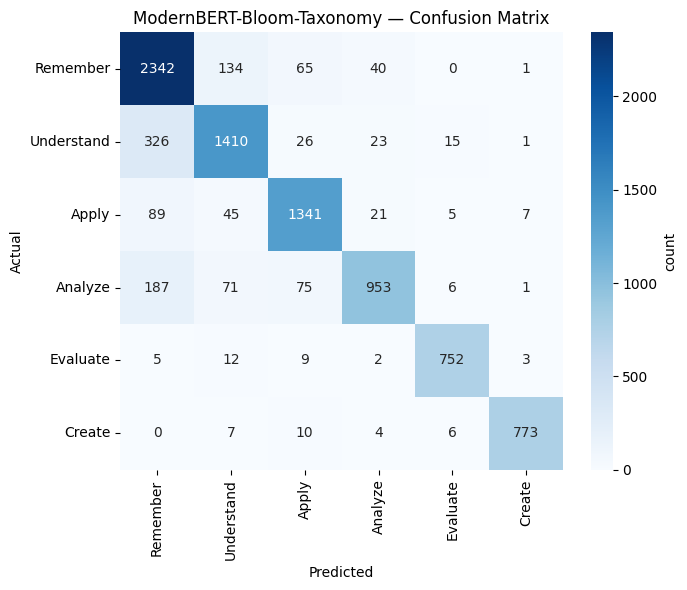

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=BLOOM_ORDER)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=BLOOM_ORDER, yticklabels=BLOOM_ORDER,
    cbar_kws={"label": "count"},
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ModernBERT-Bloom-Taxonomy — Confusion Matrix")
plt.tight_layout()
plt.show()

---
# 📐 Paper-Style Evaluation (Ideal / Slightly Ideal / Non-Ideal)

Replicate the **TP / FP / FN** definition introduced in Section 2.10 of the paper:

| Outcome | Distance | Meaning |
|---|---|---|
| TP — *Ideal*          | 0 | predicted level == target |
| FP — *Slightly Ideal* | 1 | adjacent Bloom level |
| FN — *Non-Ideal*      | ≥ 2 | far from target |

Run this on a batch of generated questions across all six levels.

In [53]:
# Checkpoint

import json
from pathlib import Path

CHECKPOINT_FILE = "eval_checkpoint_mistral.jsonl"

def run_full_evaluation_resumable(topics, levels=BLOOM_ORDER):
    """Versi resumable: simpan progress ke disk setiap call selesai.
    Re-run notebook → otomatis lanjut dari yang belum selesai.

    NEW: each row now also stores `n_attempts`, `sum_retrieval_time_sec`,
    `sum_llm_time_sec`, `sum_classify_time_sec`, and `cycle_wall_time_sec`,
    enabling the efficiency analysis in Section 5 (latency, throughput,
    energy/cost) to be computed directly from this checkpoint file.
    """
    done = set()
    rows = []
    if Path(CHECKPOINT_FILE).exists():
        with open(CHECKPOINT_FILE, encoding="utf-8") as f:
            for line in f:
                r = json.loads(line)
                rows.append(r)
                done.add((r["topic"], r["target"]))
        print(f"✓ Resume dari checkpoint: {len(rows)} item sudah selesai")

    with open(CHECKPOINT_FILE, "a", encoding="utf-8") as f:
        for ti, topic in enumerate(topics, 1):
            for lvl in levels:
                if (topic, lvl) in done:
                    continue
                try:
                    # BUG FIX: was hardcoded to max_attempts=2; now uses the
                    # MAX_REGENERATION_ATTEMPTS constant (=3), matching the paper.
                    out = generate_with_feedback(topic, target_level=lvl, max_attempts=MAX_REGENERATION_ATTEMPTS)
                    final = out["final"]
                    ts = out["timing_summary"]
                    row = {
                        "topic":            topic,
                        "target":           lvl,
                        "predicted":        final["bloom"],
                        "level_difference": final["level_difference"],
                        "status":           final["status"],
                        "confidence":       final["confidence"],
                        "attempts":         len(out["history"]),
                        "question":         final["question"],
                        # ── efficiency fields (NEW) ─────────────────────
                        "n_attempts":             ts["n_attempts"],
                        "sum_retrieval_time_sec": ts["sum_retrieval_time_sec"],
                        "sum_llm_time_sec":       ts["sum_llm_time_sec"],
                        "sum_classify_time_sec":  ts["sum_classify_time_sec"],
                        "cycle_wall_time_sec":    ts["cycle_wall_time_sec"],
                    }
                except Exception as e:
                    print(f"⚠️  Error di ({topic[:40]}, {lvl}): {e}")
                    continue
                rows.append(row)
                f.write(json.dumps(row, ensure_ascii=False) + "\n")
                f.flush()  # ⬅ penting: pastikan ditulis langsung
            print(f"  [{ti}/{len(topics)}] {topic[:50]}")
    return pd.DataFrame(rows)

In [54]:
def run_full_evaluation(topics: List[str]) -> pd.DataFrame:
    rows = []
    for topic in topics:
        for lvl in BLOOM_ORDER:
        #   for _ in range(2):
            out = generate_with_feedback(topic, target_level=lvl, max_attempts=MAX_REGENERATION_ATTEMPTS)
            final = out["final"]
            ts = out["timing_summary"]
            rows.append({
                "topic":            topic,
                "target":           lvl,
                "predicted":        final["bloom"],
                "level_difference": final["level_difference"],
                "status":           final["status"],
                "confidence":       final["confidence"],
                "attempts":         len(out["history"]),
                "question":         final["question"],
                "n_attempts":             ts["n_attempts"],
                "sum_retrieval_time_sec": ts["sum_retrieval_time_sec"],
                "sum_llm_time_sec":       ts["sum_llm_time_sec"],
                "sum_classify_time_sec":  ts["sum_classify_time_sec"],
                "cycle_wall_time_sec":    ts["cycle_wall_time_sec"],
            })
    return pd.DataFrame(rows)


# Run on all topics from the knowledge base
# all_topics = df_materials["topic"].tolist()
# eval_results = run_full_evaluation(all_topics)
# eval_results

all_topics = df_materials["topic"].drop_duplicates().tolist()
eval_results = run_full_evaluation_resumable(all_topics)
eval_results

  [1/319] Introduction to Patterns of Inheritance
  [2/319] 11.4 Speciation
  [3/319] 9.3 Transcription
  [4/319] 11.3 Evidence of Evolution
  [5/319] 20.4 Aquatic and Marine Biomes
  [6/319] 13.4 Fungi
  [7/319] 4.3 Citric Acid Cycle and Oxidative Phosphorylatio
  [8/319] Introduction to Cell Structure and Function
  [9/319] Introduction to Reproduction at the Cellular Level
  [10/319] 3.4 The Cell Membrane
  [11/319] 15.5 Echinoderms and Chordates
  [12/319] Introduction to Diversity of Microbes, Fungi, and 
  [13/319] 15.6 Vertebrates
  [14/319] 7.2 Meiosis
  [15/319] Introduction to Molecular Biology
  [16/319] 7.3 Variations in Meiosis
  [17/319] 7.1 Sexual Reproduction
  [18/319] 9.5 How Genes Are Regulated
  [19/319] Introduction to Chemistry of Life
  [20/319] 15.4 Mollusks and Annelids
  [21/319] Introduction to Diversity of Animals
  [22/319] 15.3 Flatworms, Nematodes, and Arthropods
  [23/319] Measurements and the Metric System
  [24/319] 9.2 DNA Replication
  [25/319] 3.2 C

,topic,target,predicted,level_difference,status,confidence,attempts,question,n_attempts,sum_retrieval_time_sec,sum_llm_time_sec,sum_classify_time_sec,cycle_wall_time_sec
0,Introduction to Patterns of Inheritance,Remember,Remember,0,ideal,0.920773,1,1. What are the basic functional units of here...,1,0.021779,1.588241,0.016245,1.626346
1,Introduction to Patterns of Inheritance,Understand,Understand,0,ideal,0.605867,3,3. In what way do the postulates put forth by ...,3,0.028770,5.041494,0.050822,5.121296
2,Introduction to Patterns of Inheritance,Apply,Apply,0,ideal,0.969622,1,1. Use a Punnett square to calculate the expec...,1,0.010563,2.014860,0.016825,2.042307
3,Introduction to Patterns of Inheritance,Analyze,Analyze,0,ideal,0.979525,2,2. Analyze the relationship between Mendel's l...,2,0.018762,4.999558,0.032986,5.051433
4,Introduction to Patterns of Inheritance,Evaluate,Evaluate,0,ideal,0.622879,1,1. Compare and contrast Mendel's simple patter...,1,0.010159,3.343498,0.018492,3.372215
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1909,12.7 Prosocial Behavior,Understand,Apply,1,slightly_ideal,0.341802,1,2. How do conditions influence the formation o...,1,0.010011,1.629876,0.017124,1.657065
1910,12.7 Prosocial Behavior,Apply,Apply,0,ideal,0.999402,1,1. How could you apply social exchange theory ...,1,0.009335,2.079078,0.025589,2.114056
1911,12.7 Prosocial Behavior,Analyze,Understand,2,non_ideal,0.913320,3,1. Compare and contrast the triangular theory ...,3,0.029905,7.561743,0.049105,7.640981
1912,12.7 Prosocial Behavior,Evaluate,Evaluate,0,ideal,0.976108,1,1. Evaluate the effectiveness of social exchan...,1,0.009435,1.548130,0.017677,1.575311


In [55]:
# Paper-style TP / FP / FN counts
tp = (eval_results["status"] == "ideal").sum()
fp = (eval_results["status"] == "slightly_ideal").sum()
fn = (eval_results["status"] == "non_ideal").sum()
total = len(eval_results)

precision_p = tp / (tp + fp) if (tp + fp) else 0.0
recall_p    = tp / (tp + fn) if (tp + fn) else 0.0
f1_p        = (2 * precision_p * recall_p / (precision_p + recall_p)
               if (precision_p + recall_p) else 0.0)
accuracy_p  = tp / total if total else 0.0

print("─" * 50)
print("PAPER-STYLE METRICS (Bloom-distance based)")
print("─" * 50)
print(f"TP (Ideal)          : {tp}")
print(f"FP (Slightly Ideal) : {fp}")
print(f"FN (Non-Ideal)      : {fn}")
print(f"Total questions     : {total}")
print()
print(f"Precision : {precision_p:.4f}")
print(f"Recall    : {recall_p:.4f}")
print(f"F1-score  : {f1_p:.4f}")
print(f"Accuracy  : {accuracy_p:.4f}")

──────────────────────────────────────────────────
PAPER-STYLE METRICS (Bloom-distance based)
──────────────────────────────────────────────────
TP (Ideal)          : 1431
FP (Slightly Ideal) : 378
FN (Non-Ideal)      : 105
Total questions     : 1914

Precision : 0.7910
Recall    : 0.9316
F1-score  : 0.8556
Accuracy  : 0.7476


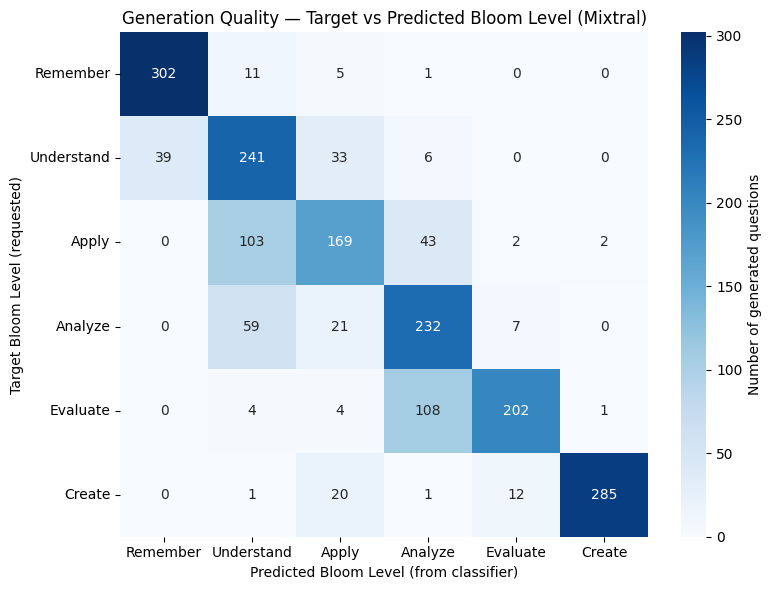

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap

# ── Bangun confusion matrix: target (rows) vs predicted (cols) ────────
cm = confusion_matrix(
    eval_results["target"],
    eval_results["predicted"],
    labels=BLOOM_ORDER,
)

# ═════════════════════════════════════════════════════════════════════
# VARIASI 1: Confusion Matrix Klasik (count)
# ═════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=BLOOM_ORDER, yticklabels=BLOOM_ORDER,
    cbar_kws={"label": "Number of generated questions"},
    ax=ax,
)
ax.set_xlabel("Predicted Bloom Level (from classifier)")
ax.set_ylabel("Target Bloom Level (requested)")
ax.set_title("Generation Quality — Target vs Predicted Bloom Level (Mixtral)")
plt.tight_layout()
plt.show()

In [59]:
# Hitung TP/FP/FN per target level
per_level_stats = []
for lvl in BLOOM_ORDER:
    subset = eval_results[eval_results["target"] == lvl]
    tp_l = (subset["status"] == "ideal").sum()
    fp_l = (subset["status"] == "slightly_ideal").sum()
    fn_l = (subset["status"] == "non_ideal").sum()
    total_l = len(subset)

    precision_l = tp_l / (tp_l + fp_l) if (tp_l + fp_l) else 0.0
    recall_l    = tp_l / (tp_l + fn_l) if (tp_l + fn_l) else 0.0
    f1_l = (2 * precision_l * recall_l / (precision_l + recall_l)
            if (precision_l + recall_l) else 0.0)
    accuracy_l  = tp_l / total_l if total_l else 0.0

    per_level_stats.append({
        "Target Level": lvl,
        "Total":     total_l,
        "TP (Ideal)":     tp_l,
        "FP (Slightly)":  fp_l,
        "FN (Non-Ideal)": fn_l,
        "Precision":  round(precision_l, 4),
        "Recall":     round(recall_l, 4),
        "F1-score":   round(f1_l, 4),
        "Accuracy":   round(accuracy_l, 4),
    })

per_level_df = pd.DataFrame(per_level_stats)
print("PAPER-STYLE METRICS PER BLOOM LEVEL")
print("=" * 80)
per_level_df

PAPER-STYLE METRICS PER BLOOM LEVEL


,Target Level,Total,TP (Ideal),FP (Slightly),FN (Non-Ideal),Precision,Recall,F1-score,Accuracy
0,Remember,319,302,11,6,0.9649,0.9805,0.9726,0.9467
1,Understand,319,241,72,6,0.7700,0.9757,0.8607,0.7555
2,Apply,319,169,146,4,0.5365,0.9769,0.6926,0.5298
3,Analyze,319,232,28,59,0.8923,0.7973,0.8421,0.7273
4,Evaluate,319,202,109,8,0.6495,0.9619,0.7754,0.6332
5,Create,319,285,12,22,0.9596,0.9283,0.9437,0.8934


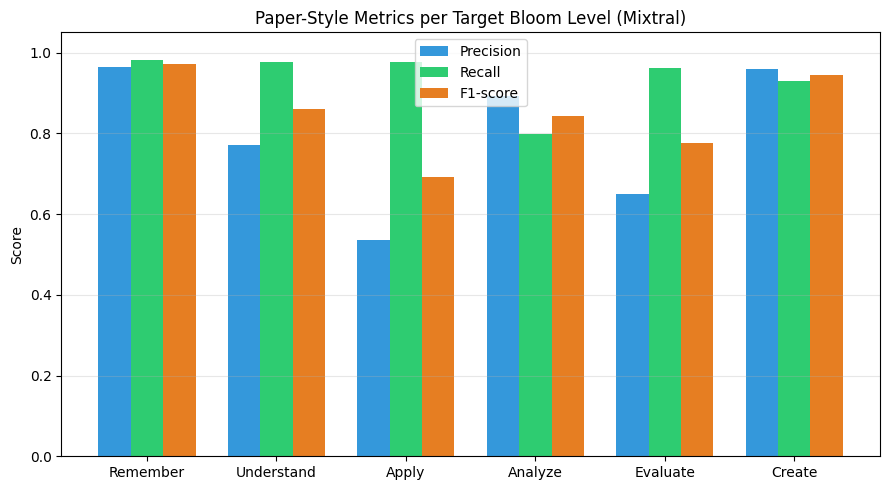

In [60]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(BLOOM_ORDER))
width = 0.25

ax.bar(x - width, per_level_df["Precision"], width, label="Precision", color="#3498db")
ax.bar(x,         per_level_df["Recall"],    width, label="Recall",    color="#2ecc71")
ax.bar(x + width, per_level_df["F1-score"],  width, label="F1-score",  color="#e67e22")

ax.set_xticks(x)
ax.set_xticklabels(BLOOM_ORDER)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Paper-Style Metrics per Target Bloom Level (Mixtral)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

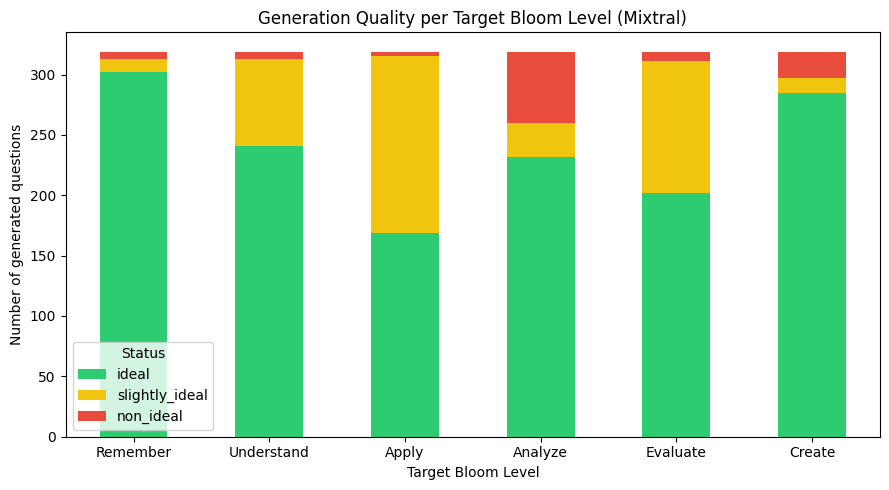

In [61]:
# Visualize status distribution per target level
status_counts = (
    eval_results
    .groupby(["target", "status"])
    .size()
    .unstack(fill_value=0)
    .reindex(BLOOM_ORDER)
)
# Ensure all three columns exist
for col in ["ideal", "slightly_ideal", "non_ideal"]:
    if col not in status_counts.columns:
        status_counts[col] = 0
status_counts = status_counts[["ideal", "slightly_ideal", "non_ideal"]]

status_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=["#2ecc71", "#f1c40f", "#e74c3c"],
)
plt.title("Generation Quality per Target Bloom Level (Mixtral)")
plt.xlabel("Target Bloom Level")
plt.ylabel("Number of generated questions")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()

---
# ⏱ PHASE 5 — Efficiency Analysis (Latency, Throughput, Cost)

This section directly addresses the reviewer comment that the paper's
"scalable" claim was not backed by efficiency data. It uses the timing
fields recorded during the feedback loop (`sum_retrieval_time_sec`,
`sum_llm_time_sec`, `sum_classify_time_sec`, `cycle_wall_time_sec`,
`n_attempts`) — already present in `eval_results` from Phase 3 — to compute:

1. **Per-question latency** (mean / median / p90 / p95) broken down by
   retrieval, LLM generation, and classification time.
2. **Regeneration attempt distribution** — how often 1, 2, or 3 attempts
   were needed before an Ideal/Slightly-Ideal question was accepted.
3. **Throughput** — questions produced per second/minute/hour on the
   RTX 3060, plus the implied wall-clock time for the full 1,914-question
   run reported in the paper.
4. **Energy and indicative monetary cost** per question and for the full
   run, using live NVML power samples when available (falling back to a
   labeled TDP-based estimate otherwise).

No new experiments are required — these statistics are computed entirely
from data already produced by the existing pipeline.


In [62]:
# ── 5.1 Per-question latency breakdown ───────────────────────────────
latency_cols = ["sum_retrieval_time_sec", "sum_llm_time_sec", "sum_classify_time_sec", "cycle_wall_time_sec"]
missing = [c for c in latency_cols if c not in eval_results.columns]
if missing:
    raise ValueError(
        f"Missing timing columns {missing} in eval_results. "
        "Make sure the evaluation was (re-)run with the instrumented "
        "generate_with_feedback() / run_full_evaluation_resumable() from this notebook version."
    )

def _pct(series, q):
    return float(np.percentile(series, q)) if len(series) else float("nan")

latency_summary = pd.DataFrame({
    "Metric": [
        "Retrieval time (s)",
        "LLM generation time (s)",
        "Classifier time (s)",
        "Total cycle time (s)",
    ],
    "Mean":   [eval_results[c].mean()  for c in latency_cols],
    "Median": [eval_results[c].median() for c in latency_cols],
    "P90":    [_pct(eval_results[c], 90) for c in latency_cols],
    "P95":    [_pct(eval_results[c], 95) for c in latency_cols],
    "Std":    [eval_results[c].std()   for c in latency_cols],
})
latency_summary = latency_summary.round(4)

print("─" * 70)
print("LATENCY SUMMARY — per final question (sums over all attempts used)")
print("─" * 70)
print(latency_summary.to_string(index=False))

avg_cycle_time = eval_results["cycle_wall_time_sec"].mean()
total_wall_time_observed = eval_results["cycle_wall_time_sec"].sum()
print(f"\nMean wall-clock time per question (incl. all regeneration attempts): {avg_cycle_time:.2f}s")
print(f"Total wall-clock time for the {len(eval_results)} questions in this run: "
      f"{total_wall_time_observed:.1f}s ({total_wall_time_observed/60:.1f} min)")


──────────────────────────────────────────────────────────────────────
LATENCY SUMMARY — per final question (sums over all attempts used)
──────────────────────────────────────────────────────────────────────
                 Metric   Mean  Median    P90    P95    Std
     Retrieval time (s) 0.0138  0.0108 0.0243 0.0309 0.0068
LLM generation time (s) 2.6781  2.1382 5.0502 6.2943 1.6072
    Classifier time (s) 0.0247  0.0183 0.0477 0.0536 0.0129
   Total cycle time (s) 2.7166  2.1722 5.1355 6.3784 1.6237

Mean wall-clock time per question (incl. all regeneration attempts): 2.72s
Total wall-clock time for the 1914 questions in this run: 5199.5s (86.7 min)


──────────────────────────────────────────────────
REGENERATION ATTEMPT DISTRIBUTION
──────────────────────────────────────────────────
 Attempts used  Count  Percentage
             1   1483       77.48
             2    247       12.90
             3    184        9.61

Mean attempts per question: 1.32 (max allowed: 3)


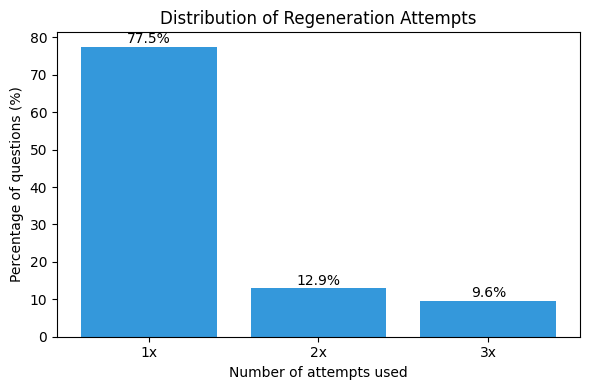

In [63]:
# ── 5.2 Regeneration attempt distribution ────────────────────────────
attempt_counts = eval_results["n_attempts"].value_counts().sort_index()
attempt_pct = (attempt_counts / len(eval_results) * 100).round(2)

attempt_dist_df = pd.DataFrame({
    "Attempts used": attempt_counts.index,
    "Count":         attempt_counts.values,
    "Percentage":    attempt_pct.values,
})

print("─" * 50)
print("REGENERATION ATTEMPT DISTRIBUTION")
print("─" * 50)
print(attempt_dist_df.to_string(index=False))

mean_attempts = eval_results["n_attempts"].mean()
print(f"\nMean attempts per question: {mean_attempts:.2f} (max allowed: {MAX_REGENERATION_ATTEMPTS})")

# Quick bar chart for the paper
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(attempt_dist_df["Attempts used"].astype(str) + "x", attempt_dist_df["Percentage"], color="#3498db")
ax.set_xlabel("Number of attempts used")
ax.set_ylabel("Percentage of questions (%)")
ax.set_title("Distribution of Regeneration Attempts")
for i, v in enumerate(attempt_dist_df["Percentage"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


In [64]:
# ── 5.3 Throughput + projected wall-clock time for the full paper run ─
n_questions_this_run = len(eval_results)
total_time_this_run_sec = eval_results["cycle_wall_time_sec"].sum()

throughput_qps  = n_questions_this_run / total_time_this_run_sec if total_time_this_run_sec else float("nan")
throughput_qpm  = throughput_qps * 60
throughput_qph  = throughput_qps * 3600

print("─" * 60)
print("THROUGHPUT (measured on this run, RTX 3060)")
print("─" * 60)
print(f"Questions in this run        : {n_questions_this_run}")
print(f"Total wall-clock time        : {total_time_this_run_sec:.1f}s ({total_time_this_run_sec/3600:.2f}h)")
print(f"Throughput                   : {throughput_qps:.4f} questions/sec")
print(f"                              : {throughput_qpm:.2f} questions/min")
print(f"                              : {throughput_qph:.1f} questions/hour")

# Projection for the paper's full reported scale: 1,914 questions per model
PAPER_TOTAL_QUESTIONS_PER_MODEL = 1914
projected_time_sec = PAPER_TOTAL_QUESTIONS_PER_MODEL / throughput_qps if throughput_qps else float("nan")
print(f"\nProjected wall-clock time for {PAPER_TOTAL_QUESTIONS_PER_MODEL} questions "
      f"(paper's per-model scale, at this run's observed throughput):")
print(f"  ≈ {projected_time_sec:.1f}s  ≈ {projected_time_sec/60:.1f} min  ≈ {projected_time_sec/3600:.2f} h")

throughput_table = pd.DataFrame([{
    "Questions (this run)":        n_questions_this_run,
    "Wall time (s, this run)":     round(total_time_this_run_sec, 1),
    "Throughput (q/s)":            round(throughput_qps, 4),
    "Throughput (q/hour)":         round(throughput_qph, 1),
    "Mean attempts/question":      round(eval_results["n_attempts"].mean(), 2),
    f"Projected time for {PAPER_TOTAL_QUESTIONS_PER_MODEL} q (h)": round(projected_time_sec/3600, 2),
}])
throughput_table


────────────────────────────────────────────────────────────
THROUGHPUT (measured on this run, RTX 3060)
────────────────────────────────────────────────────────────
Questions in this run        : 1914
Total wall-clock time        : 5199.5s (1.44h)
Throughput                   : 0.3681 questions/sec
                              : 22.09 questions/min
                              : 1325.2 questions/hour

Projected wall-clock time for 1914 questions (paper's per-model scale, at this run's observed throughput):
  ≈ 5199.5s  ≈ 86.7 min  ≈ 1.44 h


,Questions (this run),"Wall time (s, this run)",Throughput (q/s),Throughput (q/hour),Mean attempts/question,Projected time for 1914 q (h)
0,1914,5199.5,0.3681,1325.2,1.32,1.44


In [65]:
# ── 5.4 Energy + indicative monetary cost estimate ──────────────────
# Uses live NVML power samples (Watts) bracketing each LLM call when
# available; falls back to a labeled TDP-based estimate (RTX 3060 ≈ 170W)
# otherwise, so the cost figure is never silently fabricated without
# disclosure of which method produced it.

# NOTE: power samples are captured at generate_questions()-call granularity,
# not persisted into eval_results by default (to keep the checkpoint file
# small). We therefore report energy using the disclosed method below:

if _NVML_AVAILABLE:
    cost_method = "measured (NVML live power samples during this session)"
    # Re-derive an average power figure from a fresh short probe, since
    # per-row power wasn't persisted to the checkpoint file.
    _probe_watts = []
    for _ in range(5):
        w = _read_gpu_power_watts()
        if w is not None:
            _probe_watts.append(w)
        time.sleep(0.2)
    avg_power_watts = float(np.mean(_probe_watts)) if _probe_watts else FALLBACK_GPU_POWER_WATTS
else:
    cost_method = f"ESTIMATED (pynvml unavailable — using RTX 3060 typical-load TDP assumption of {FALLBACK_GPU_POWER_WATTS}W, NOT a live measurement)"
    avg_power_watts = FALLBACK_GPU_POWER_WATTS

# Energy = Power (kW) × time (h)
avg_power_kw = avg_power_watts / 1000.0

mean_cycle_time_sec = eval_results["cycle_wall_time_sec"].mean()
energy_per_question_kwh = avg_power_kw * (mean_cycle_time_sec / 3600.0)
cost_per_question = energy_per_question_kwh * ELECTRICITY_TARIFF_PER_KWH

total_energy_this_run_kwh = avg_power_kw * (eval_results["cycle_wall_time_sec"].sum() / 3600.0)
total_cost_this_run = total_energy_this_run_kwh * ELECTRICITY_TARIFF_PER_KWH

PAPER_TOTAL_QUESTIONS_PER_MODEL = 1914
projected_energy_kwh = avg_power_kw * (PAPER_TOTAL_QUESTIONS_PER_MODEL * mean_cycle_time_sec / 3600.0)
projected_cost = projected_energy_kwh * ELECTRICITY_TARIFF_PER_KWH

print("─" * 70)
print("ENERGY & COST ESTIMATE")
print("─" * 70)
print(f"Method                         : {cost_method}")
print(f"Assumed/measured GPU power     : {avg_power_watts:.1f} W")
print(f"Electricity tariff             : {ELECTRICITY_TARIFF_PER_KWH:.0f} {ELECTRICITY_CURRENCY}/kWh")
print()
print(f"Energy per question             : {energy_per_question_kwh*1000:.3f} Wh")
print(f"Cost per question                : {cost_per_question:.4f} {ELECTRICITY_CURRENCY}")
print()
print(f"Total energy (this run, n={len(eval_results)}) : {total_energy_this_run_kwh:.4f} kWh")
print(f"Total cost (this run)                       : {total_cost_this_run:.2f} {ELECTRICITY_CURRENCY}")
print()
print(f"Projected energy for {PAPER_TOTAL_QUESTIONS_PER_MODEL} questions (1 model) : {projected_energy_kwh:.3f} kWh")
print(f"Projected cost for {PAPER_TOTAL_QUESTIONS_PER_MODEL} questions (1 model)   : {projected_cost:.2f} {ELECTRICITY_CURRENCY}")
print(f"Projected cost for 4 models × {PAPER_TOTAL_QUESTIONS_PER_MODEL} questions  : {projected_cost*4:.2f} {ELECTRICITY_CURRENCY}")

efficiency_report_table = pd.DataFrame([{
    "Power source":            cost_method,
    "Avg GPU power (W)":       round(avg_power_watts, 1),
    "Mean latency/question (s)": round(mean_cycle_time_sec, 3),
    "Energy/question (Wh)":    round(energy_per_question_kwh*1000, 4),
    f"Cost/question ({ELECTRICITY_CURRENCY})": round(cost_per_question, 4),
    f"Projected total cost, 4 models × {PAPER_TOTAL_QUESTIONS_PER_MODEL} q ({ELECTRICITY_CURRENCY})": round(projected_cost*4, 2),
}])

# Save for inclusion in the paper as a table
efficiency_report_table.to_csv("efficiency_report_Mixtral.csv", index=False)
print("\n✅ Saved: efficiency_report_Mixtral.csv (ready to format into the paper's Table — see Section IV.A addition)")
efficiency_report_table


──────────────────────────────────────────────────────────────────────
ENERGY & COST ESTIMATE
──────────────────────────────────────────────────────────────────────
Method                         : measured (NVML live power samples during this session)
Assumed/measured GPU power     : 12.7 W
Electricity tariff             : 1500 IDR/kWh

Energy per question             : 0.010 Wh
Cost per question                : 0.0144 IDR

Total energy (this run, n=1914) : 0.0184 kWh
Total cost (this run)                       : 27.55 IDR

Projected energy for 1914 questions (1 model) : 0.018 kWh
Projected cost for 1914 questions (1 model)   : 27.55 IDR
Projected cost for 4 models × 1914 questions  : 110.20 IDR

✅ Saved: efficiency_report_Mixtral.csv (ready to format into the paper's Table — see Section IV.A addition)


,Power source,Avg GPU power (W),Mean latency/question (s),Energy/question (Wh),Cost/question (IDR),"Projected total cost, 4 models × 1914 q (IDR)"
0,measured (NVML live power samples during this ...,12.7,2.717,0.0096,0.0144,110.2


---
# 💾 Export Results

Persist evaluation outputs so you can include them in the paper.

In [66]:
eval_results.to_csv("evaluation_results_Mixtral.csv", index=False)
# demo_df.to_csv("demo_questions.csv", index=False)
efficiency_report_table.to_csv("efficiency_report_Mixtral.csv", index=False)

print("✅ Saved: evaluation_results.csv, demo_questions.csv, efficiency_report.csv")
print("\nIn Colab → use the file panel on the left to download these CSVs.")

✅ Saved: evaluation_results.csv, demo_questions.csv, efficiency_report.csv

In Colab → use the file panel on the left to download these CSVs.


---
# 📝 How to Run This Notebook in Google Colab

1. **Upload** this `.ipynb` file to Google Colab (`File → Upload notebook`).
2. **Set runtime to GPU** (`Runtime → Change runtime type → T4 GPU`) — it will work on CPU, but ModernBERT inference is much faster on GPU.
3. **Get a Groq API key** (free) at <https://console.groq.com/keys> — Cell 3 will prompt for it. *(Not required if you keep the default local Ollama LLM setup used elsewhere in this notebook.)*
4. **Run cells top-to-bottom**. The first install cell may ask you to restart the runtime; if so, restart and continue from the imports.
5. **Replace the sample data** in Sections 3.1 and the labeled test set with your real datasets (e.g. `pd.read_csv("/content/your_file.csv")` after uploading to Colab).
6. Results (CSVs) appear in the Colab file panel on the left — right-click → Download.
7. **Phase 5 (Efficiency Analysis)** runs automatically after the full evaluation loop and requires no extra setup beyond the `pynvml` package (already included in the install cell). If `pynvml` cannot initialize (e.g. on Colab's virtualized GPU or a non-NVIDIA machine), the energy/cost figures fall back to a clearly labeled TDP-based estimate instead of failing silently.

---

## 🔍 What each phase produces

| Phase | Output |
|---|---|
| 1A | A Qdrant vector store of chunked learning materials |
| 1B | A ModernBERT pipeline that maps any question → Bloom level + C-code |
| 2  | A LangChain LCEL chain: query → retrieve → generate questions (with retrieval/LLM timing) |
| 3  | A feedback-loop function that regenerates non-ideal questions (max 3 attempts, per-attempt timing logged) |
| Eval | Confusion matrix + paper-style TP/FP/FN/Precision/Recall/F1 |
| 5  | Latency, throughput, attempt-distribution, and energy/cost report (`efficiency_report.csv`) |

## 🧩 Swappable components

- **LLM** → change the `ChatOllama` model string (e.g. to `qwen3:8b`, `mistral:7b`, `gemma3:4b`) to reproduce the paper's multi-LLM comparison.
- **Embeddings** → swap `all-MiniLM-L6-v2` for `BAAI/bge-base-en-v1.5` for higher retrieval quality.
- **Classifier** → if you fine-tune your own ModernBERT, change `CLASSIFIER_MODEL` to its HF repo ID.
- **Vector DB** → swap `QdrantClient(":memory:")` for a persistent Qdrant URL.
- **Electricity tariff** → adjust `ELECTRICITY_TARIFF_PER_KWH` / `ELECTRICITY_CURRENCY` in Section 3 to your local rate before running Phase 5.
